In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")

In [3]:
df = pd.read_pickle(r"C:\Users\Almog\Desktop\Data Science\Projects\2026\Customer Personality Analysis\Pickle files\FTS_MC1.pkl")
df.head()

,Year_Birth,Kidhome,Teenhome,Recency,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,...,Income_log,MntWines_log,MntFruits_log,MntMeatProducts_log,MntFishProducts_log,MntSweetProducts_log,MntGoldProds_log,NumDealsPurchases_log,NumWebPurchases_log,NumCatalogPurchases_log
0,-0.985345,-0.825218,-0.929894,0.307039,-0.550785,0.693904,-0.28014,-0.28383,-0.28014,-0.262111,...,0.428874,0.987816,1.432838,1.395245,1.580292,1.411082,1.061778,0.653324,1.281507,1.805279
1,-1.235733,1.032559,0.906934,-0.383664,-1.166125,-0.130463,-0.28014,-0.28383,-0.28014,-0.262111,...,-0.021774,-1.213337,-0.984548,-1.397218,-0.866776,-0.970316,-0.912490,0.042760,-1.396187,-0.405464
2,-0.317643,-0.825218,-0.929894,-0.798086,1.295237,-0.542647,-0.28014,-0.28383,-0.28014,-0.262111,...,0.843209,0.766933,1.065587,0.464698,1.317887,0.534192,0.496970,-0.817780,1.281507,0.120349
3,1.268149,1.032559,-0.929894,-0.798086,-0.550785,0.281720,-0.28014,-0.28383,-0.28014,-0.262111,...,-1.121817,-1.213337,-0.400953,-0.693351,-0.082637,-0.535416,-1.032178,0.042760,-0.674342,-1.304348
4,1.017761,1.032559,-0.929894,1.550305,0.064556,-0.130463,-0.28014,-0.28383,-0.28014,-0.262111,...,0.434166,0.269227,0.984169,0.417988,0.793822,0.685504,-0.270625,1.513864,0.559662,0.493420


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 26 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Year_Birth               2240 non-null   float64
 1   Kidhome                  2240 non-null   float64
 2   Teenhome                 2240 non-null   float64
 3   Recency                  2240 non-null   float64
 4   NumStorePurchases        2240 non-null   float64
 5   NumWebVisitsMonth        2240 non-null   float64
 6   AcceptedCmp3             2240 non-null   float64
 7   AcceptedCmp4             2240 non-null   float64
 8   AcceptedCmp5             2240 non-null   float64
 9   AcceptedCmp1             2240 non-null   float64
 10  AcceptedCmp2             2240 non-null   float64
 11  Complain                 2240 non-null   float64
 12  Response                 2240 non-null   float64
 13  tenure_years             2240 non-null   float64
 14  Education_ord           

#### Model Trainning

#### Find the Optimal Number of Clusters (K)

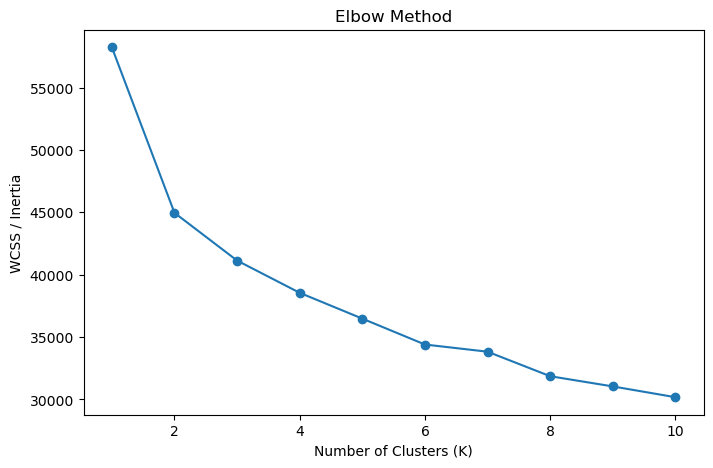

,K,WCSS_Inertia
0,1,58240.000000
1,2,44964.758343
2,3,41137.378115
3,4,38552.159881
4,5,36481.362508
5,6,34406.073920
6,7,33830.532345
7,8,31864.938466
8,9,31046.917645
9,10,30181.750100


In [17]:
from sklearn.cluster import KMeans
import pandas as pd
import matplotlib.pyplot as plt

wcss = []

K_range = range(1, 11)

for k in K_range:
    
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    kmeans.fit(df)
    
    wcss.append(kmeans.inertia_)

# Create summary table
elbow_df = pd.DataFrame({
    'K': list(K_range),
    'WCSS_Inertia': wcss
})

# Plot elbow chart
plt.figure(figsize=(8,5))

plt.plot(K_range, wcss, marker='o')

plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS / Inertia')
plt.title('Elbow Method')

plt.show()

# Display summary table
elbow_df

**Elbow Method - Determining the Optimal Number of Clusters**

To estimate the optimal number of clusters (`K`) for K-Means clustering, the Elbow Method was applied using the Within-Cluster Sum of Squares (WCSS / Inertia) metric.

The results show a sharp decrease in WCSS between:
- `K = 1` and `K = 4`
- followed by a more gradual decline afterward.

This pattern suggests that the clustering model gains substantial structure up to approximately `4-6` clusters, after which the improvement becomes progressively smaller.

Key observations:
- The largest reduction occurs between `K = 1` and `K = 2`, indicating strong initial separation in the data.
- The curve begins to flatten after approximately `K = 4`.
- Additional clusters beyond this point still improve compactness, but with diminishing returns.

Based on the Elbow Method, the most reasonable candidate range for the optimal number of clusters appears to be:

- `K = 4`
- `K = 5`
- `K = 6`

The next step will involve using the **Silhouette Score** to evaluate cluster separation quality and determine which value of `K` produces the most meaningful clustering structure.

#### Silhouette Analysis

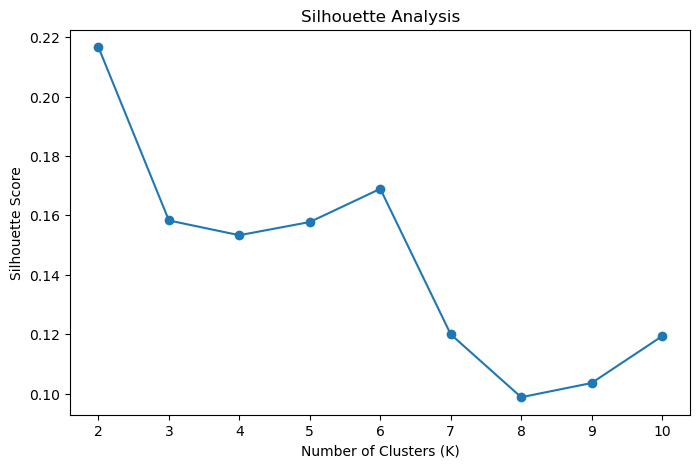

,K,Silhouette_Score
0,2,0.216628
1,3,0.158277
2,4,0.153315
3,5,0.157758
4,6,0.168942
5,7,0.119934
6,8,0.098751
7,9,0.103538
8,10,0.119313


In [23]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import pandas as pd
import matplotlib.pyplot as plt

silhouette_scores = []

K_range = range(2, 11)

for k in K_range:
    
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    cluster_labels = kmeans.fit_predict(df)
    
    score = silhouette_score(df, cluster_labels)
    
    silhouette_scores.append(score)

# Summary table
silhouette_df = pd.DataFrame({
    'K': list(K_range),
    'Silhouette_Score': silhouette_scores
})

# Plot
plt.figure(figsize=(8,5))

plt.plot(K_range, silhouette_scores, marker='o')

plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Analysis')

plt.show()

# Display results
silhouette_df

**Silhouette Analysis - Cluster Quality Evaluation**

To evaluate the quality of the clustering structure, Silhouette Analysis was performed across multiple values of `K`.

The Silhouette Score measures how well observations fit within their assigned cluster compared to neighboring clusters:
- Higher values indicate better separation and more compact clusters.
- Lower values indicate overlapping or less distinct clusters.

Key observations:
- The highest silhouette score was achieved at `K = 2` with a score of approximately `0.217`.
- Cluster quality decreases noticeably for `K = 3` through `K = 5`.
- A smaller local improvement appears at `K = 6`, though the score remains below the `K = 2` result.
- Scores decline significantly beyond `K = 6`, suggesting that adding more clusters introduces fragmentation and weaker separation.

Interpretation:
- From a purely mathematical perspective, the dataset naturally separates most strongly into **2 major groups**.
- However, the Elbow Method suggested that additional sub-structure may exist around `K = 4-6`.
- This indicates that the data may contain:
  - A strong high-level split (`K = 2`)
  - Additional finer behavioral segmentation within those broader groups.

At this stage, the most reasonable candidates for final clustering are:
- `K = 2` (strongest mathematical separation)
- `K = 4-6` (potentially richer business segmentation)

#### Clustering Model Training & Cluster Profiling

**K = 4**

In [32]:
from sklearn.cluster import KMeans

# Train KMeans model
kmeans_4 = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

# Generate cluster labels
df['Cluster_4'] = kmeans_4.fit_predict(df)

# Cluster size summary
cluster_4_summary = (
    df['Cluster_4']
    .value_counts()
    .sort_index()
    .reset_index()
)

cluster_4_summary.columns = ['Cluster', 'Customer_Count']

# Percentage
cluster_4_summary['Percentage'] = (
    cluster_4_summary['Customer_Count'] / len(df) * 100
).round(2)

cluster_4_summary

,Cluster,Customer_Count,Percentage
0,0,847,37.81
1,1,219,9.78
2,2,633,28.26
3,3,541,24.15


**KMeans Clustering (K = 4)**

A K-Means model with `4` clusters was trained on the transformed and scaled dataset.

Cluster distribution:
- Cluster 0: 37.8%
- Cluster 1: 9.8%
- Cluster 2: 28.3%
- Cluster 3: 24.2%

The clusters are relatively balanced, with Cluster 1 representing a smaller niche segment. Overall, the segmentation appears stable and suitable for further behavioral profiling.

**K = 5**

In [37]:
# Train KMeans model
kmeans_5 = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

# Generate cluster labels
df['Cluster_5'] = kmeans_5.fit_predict(df)

# Cluster size summary
cluster_5_summary = (
    df['Cluster_5']
    .value_counts()
    .sort_index()
    .reset_index()
)

cluster_5_summary.columns = ['Cluster', 'Customer_Count']

# Percentage
cluster_5_summary['Percentage'] = (
    cluster_5_summary['Customer_Count'] / len(df) * 100
).round(2)

cluster_5_summary

,Cluster,Customer_Count,Percentage
0,0,845,37.72
1,1,632,28.21
2,2,197,8.79
3,3,536,23.93
4,4,30,1.34


**KMeans Clustering (K = 5)**

A K-Means model with `5` clusters was trained on the transformed and scaled dataset.

Cluster distribution:
- Cluster 0: 37.7%
- Cluster 1: 28.2%
- Cluster 2: 8.8%
- Cluster 3: 23.9%
- Cluster 4: 1.3%

Most clusters remain reasonably balanced; however, Cluster 4 is extremely small and may represent either a niche customer segment or a fragmented outlier group. This suggests that increasing the number of clusters begins to create very narrow partitions in the customer space.

**K = 6**

In [41]:
# Train KMeans model
kmeans_6 = KMeans(
    n_clusters=6,
    random_state=42,
    n_init=10
)

# Generate cluster labels
df['Cluster_6'] = kmeans_6.fit_predict(df)

# Cluster size summary
cluster_6_summary = (
    df['Cluster_6']
    .value_counts()
    .sort_index()
    .reset_index()
)

cluster_6_summary.columns = ['Cluster', 'Customer_Count']

# Percentage
cluster_6_summary['Percentage'] = (
    cluster_6_summary['Customer_Count'] / len(df) * 100
).round(2)

cluster_6_summary

,Cluster,Customer_Count,Percentage
0,0,449,20.04
1,1,334,14.91
2,2,353,15.76
3,3,398,17.77
4,4,537,23.97
5,5,169,7.54


**KMeans Clustering (K = 6)**

A K-Means model with `6` clusters was trained on the transformed and scaled dataset.

Cluster distribution:
- Cluster 0: 20.0%
- Cluster 1: 14.9%
- Cluster 2: 15.8%
- Cluster 3: 17.8%
- Cluster 4: 24.0%
- Cluster 5: 7.5%

Compared to the previous models, the `K = 6` solution produces a more evenly distributed segmentation without creating extremely small clusters. This suggests that the customer space may support a richer multi-segment structure while still maintaining relatively stable cluster sizes.

**K = 2**

In [48]:
# Train KMeans model
kmeans_2 = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

# Generate cluster labels
df['Cluster_2'] = kmeans_2.fit_predict(df)

# Cluster size summary
cluster_2_summary = (
    df['Cluster_2']
    .value_counts()
    .sort_index()
    .reset_index()
)

cluster_2_summary.columns = ['Cluster', 'Customer_Count']

# Percentage
cluster_2_summary['Percentage'] = (
    cluster_2_summary['Customer_Count'] / len(df) * 100
).round(2)

cluster_2_summary

,Cluster,Customer_Count,Percentage
0,0,847,37.81
1,1,1393,62.19


**KMeans Clustering (K = 2)**

A K-Means model with `2` clusters was trained on the transformed and scaled dataset.

Cluster distribution:
- Cluster 0: 37.8%
- Cluster 1: 62.2%

The segmentation creates two broad customer groups with relatively balanced proportions. This result aligns with the silhouette analysis, which indicated that the strongest natural separation in the dataset occurs at `K = 2`. However, compared to higher K values, this solution may provide less detailed behavioral segmentation.

#### Cluster Profiling & Interpretation

In [52]:
cluster_candidates = [
    'Cluster_2',
    'Cluster_4',
    'Cluster_5',
    'Cluster_6'
]

for cluster_col in cluster_candidates:
    
    print(f"\n==============================")
    print(f"PROFILE: {cluster_col}")
    print(f"==============================\n")
    
    profile = (
        df
        .groupby(cluster_col)
        .mean()
        .round(2)
    )
    
    display(profile)


PROFILE: Cluster_2



,Year_Birth,Kidhome,Teenhome,Recency,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,...,MntMeatProducts_log,MntFishProducts_log,MntSweetProducts_log,MntGoldProds_log,NumDealsPurchases_log,NumWebPurchases_log,NumCatalogPurchases_log,Cluster_4,Cluster_5,Cluster_6
Cluster_2,,,,,,,,,,,,,,,,,,,,,
0,0.30,0.71,-0.20,-0.02,-0.89,0.48,-0.01,-0.26,-0.28,-0.26,...,-1.03,-0.71,-0.69,-0.78,-0.25,-0.95,-0.99,0.00,0.01,1.41
1,-0.18,-0.43,0.12,0.01,0.54,-0.29,0.01,0.16,0.17,0.16,...,0.62,0.43,0.42,0.48,0.15,0.58,0.60,2.23,1.97,2.90



PROFILE: Cluster_4



,Year_Birth,Kidhome,Teenhome,Recency,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,...,MntMeatProducts_log,MntFishProducts_log,MntSweetProducts_log,MntGoldProds_log,NumDealsPurchases_log,NumWebPurchases_log,NumCatalogPurchases_log,Cluster_5,Cluster_6,Cluster_2
Cluster_4,,,,,,,,,,,,,,,,,,,,,
0,0.30,0.71,-0.20,-0.02,-0.89,0.48,-0.01,-0.26,-0.28,-0.26,...,-1.03,-0.71,-0.69,-0.78,-0.25,-0.95,-0.99,0.01,1.41,0.0
1,-0.02,-0.75,-0.73,0.01,0.75,-0.97,0.26,0.90,2.51,2.05,...,1.18,0.88,0.93,0.65,-0.85,0.61,1.16,2.21,4.31,1.0
2,-0.12,-0.68,-0.11,0.06,0.84,-0.73,-0.13,-0.16,-0.27,-0.24,...,0.90,0.92,0.87,0.60,-0.23,0.54,0.85,1.00,1.48,1.0
3,-0.32,-0.01,0.75,-0.04,0.11,0.49,0.07,0.23,-0.26,-0.13,...,0.08,-0.32,-0.32,0.26,1.00,0.61,0.09,3.01,3.98,1.0



PROFILE: Cluster_5



,Year_Birth,Kidhome,Teenhome,Recency,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,...,MntMeatProducts_log,MntFishProducts_log,MntSweetProducts_log,MntGoldProds_log,NumDealsPurchases_log,NumWebPurchases_log,NumCatalogPurchases_log,Cluster_4,Cluster_6,Cluster_2
Cluster_5,,,,,,,,,,,,,,,,,,,,,
0,0.30,0.71,-0.21,-0.01,-0.89,0.48,-0.02,-0.26,-0.28,-0.26,...,-1.02,-0.71,-0.68,-0.78,-0.25,-0.95,-0.99,0.00,1.41,0.00
1,-0.13,-0.68,-0.12,0.05,0.84,-0.73,-0.13,-0.16,-0.27,-0.25,...,0.90,0.92,0.87,0.60,-0.23,0.54,0.85,2.00,1.48,1.00
2,-0.03,-0.74,-0.75,0.01,0.75,-1.03,0.23,0.70,2.49,2.06,...,1.22,0.95,1.00,0.66,-0.86,0.62,1.17,1.01,4.21,1.00
3,-0.32,-0.01,0.75,-0.05,0.10,0.49,0.07,0.20,-0.26,-0.13,...,0.08,-0.31,-0.31,0.26,1.00,0.61,0.09,3.00,3.98,1.00
4,-0.06,-0.70,-0.13,-0.02,0.73,-0.06,0.62,2.51,1.90,1.50,...,0.53,-0.05,-0.02,0.53,-0.45,0.33,0.88,1.27,4.70,0.93



PROFILE: Cluster_6



,Year_Birth,Kidhome,Teenhome,Recency,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,...,MntMeatProducts_log,MntFishProducts_log,MntSweetProducts_log,MntGoldProds_log,NumDealsPurchases_log,NumWebPurchases_log,NumCatalogPurchases_log,Cluster_4,Cluster_5,Cluster_2
Cluster_6,,,,,,,,,,,,,,,,,,,,,
0,0.75,0.66,-0.82,-0.08,-0.90,0.70,0.05,-0.28,-0.28,-0.26,...,-0.93,-0.41,-0.41,-0.48,-0.25,-0.83,-0.95,0.00,0.00,0.0
1,-0.21,-0.57,0.62,0.11,0.95,-0.29,-0.18,-0.16,-0.27,-0.21,...,0.66,0.79,0.86,0.62,0.30,0.80,0.65,2.01,1.03,1.0
2,-0.05,-0.77,-0.89,0.01,0.73,-1.17,-0.04,-0.13,-0.28,0.30,...,1.17,1.09,0.90,0.60,-0.78,0.30,1.09,1.86,1.14,1.0
3,-0.21,0.76,0.49,0.05,-0.88,0.22,-0.09,-0.25,-0.28,-0.26,...,-1.14,-1.05,-1.00,-1.13,-0.25,-1.08,-1.04,0.00,0.02,0.0
4,-0.32,-0.02,0.74,-0.05,0.10,0.49,0.07,0.23,-0.26,-0.13,...,0.07,-0.33,-0.33,0.26,0.99,0.61,0.08,3.00,3.01,1.0
5,0.03,-0.74,-0.70,-0.00,0.74,-0.96,0.27,1.18,3.34,1.52,...,1.16,0.76,0.91,0.64,-0.88,0.60,1.15,1.00,2.27,1.0


**Cluster Profiling & Candidate Evaluation**

Multiple K-Means clustering candidates (`K = 2, 4, 5, 6`) were profiled and compared using cluster distributions, silhouette analysis, and behavioral feature patterns.

Key observations:
- `K = 2` produced the strongest mathematical separation but resulted in very broad customer groups.
- `K = 5` introduced a very small cluster (~1.3%), suggesting possible over-segmentation.
- `K = 4` created stable and interpretable segments with balanced distributions.
- `K = 6` produced the richest and most behaviorally differentiated segmentation while maintaining relatively healthy cluster sizes.

Based on the balance between mathematical quality, cluster stability, and business interpretability, the `K = 6` model was selected as the **champion clustering solution** for the project.

#### Champion Model - K = 6 Cluster Overview

**Cluster 0 - Low Engagement Customers**
Customers with low spending, weak purchasing activity, and minimal campaign engagement. Represents a lower-value and less active segment.

**Cluster 1 - Active Multi-Channel Customers**
Highly engaged customers with strong purchasing behavior across multiple channels, including web and catalog activity.

**Cluster 2 - High-Value Loyal Customers**
High-spending and highly responsive customers with strong catalog purchasing behavior and premium characteristics.

**Cluster 3 - Family-Oriented Low Spenders**
Customers with stronger household/family indicators but relatively low spending and lower overall engagement.

**Cluster 4 - Deal-Driven Customers**
Customers characterized by high deal purchase activity and promotion sensitivity, suggesting price-conscious engagement behavior.

**Cluster 5 - Premium Campaign Responders**
A highly valuable segment with strong spending behavior and exceptionally high campaign acceptance rates, potentially representing VIP or highly marketable customers.

#### Cluster Naming & Business Interpretation

| Cluster | Segment Name                  | Behavioral Traits                                                                                       | Business Value                                                            | Recommended Action                                                                                             |
| ------- | ----------------------------- | ------------------------------------------------------------------------------------------------------- | ------------------------------------------------------------------------- | -------------------------------------------------------------------------------------------------------------- |
| 0       | Dormant Low-Value Customers   | Low spending, weak purchasing activity, low engagement across channels, minimal campaign responsiveness | Low immediate revenue contribution but potential reactivation opportunity | Launch re-engagement campaigns, simplified offers, and low-cost retention workflows                            |
| 1       | Active Omni-Channel Customers | Strong purchasing activity across web, catalog, and store channels with balanced engagement             | Stable and valuable customer base with consistent activity                | Maintain engagement through personalized recommendations and cross-channel marketing                           |
| 2       | Premium Loyal Customers       | High spending behavior, strong catalog purchases, high engagement, premium behavioral profile           | High customer lifetime value and strong retention potential               | Prioritize loyalty programs, exclusive offers, and premium customer experiences                                |
| 3       | Family Budget Customers       | Family-oriented purchasing patterns with lower overall spending and moderate engagement                 | Moderate long-term value with price-sensitive behavior                    | Promote bundles, family-oriented offers, and value-driven campaigns                                            |
| 4       | Deal-Driven Customers         | High promotion and discount sensitivity, active deal purchasing behavior                                | Strong transactional activity but potentially lower margins               | Use targeted discounts, flash sales, and promotion-based automations strategically                             |
| 5       | VIP Campaign Responders       | Extremely high campaign responsiveness combined with strong spending behavior                           | Highly marketable and highly responsive premium segment                   | Trigger VIP workflows, early-access campaigns, premium retention strategies, and high-priority personalization |
